In [8]:
import numpy
import scipy.special

# neural network class definition
class neuralNetwork:

    # initialise the neural network
    def __init__(self, inputnodes, hiddennodes, outputnodes, learningrate):
        # set number of nodes in each input, hidden, output layer
        self.inodes = inputnodes
        self.hnodes = hiddennodes
        self.onodes = outputnodes
        
        # link weight matrices, wih and who
        # weights inside the arrays are w_i_j, where link is from node i to node j in the next layer
        # w11 w21
        # w12 w22 etc
        self.wih = numpy.random.normal(0.0, pow(self.hnodes, -0.5), (self.hnodes, self.inodes))
        self.who = numpy.random.normal(0.0, pow(self.onodes, -0.5), (self.onodes, self.hnodes))
        
        # learning rate
        self.lr = learningrate
        
        # activation function is the sigmoid function
        self.activation_function = lambda x: scipy.special.expit(x)
        pass

    # train the neural network
    def train(self, inputs_list, targets_list):
        # convert inputs list to 2d array
        inputs = numpy.array(inputs_list, ndmin=2).T
        targets = numpy.array(targets_list, ndmin=2).T
        
        # calculate signals into hidden layer
        hidden_inputs = numpy.dot(self.wih, inputs)
        # calculate the signals emerging from hidden layer
        hidden_outputs = self.activation_function(hidden_inputs)
        
        # calculate signals into final output layer
        final_inputs = numpy.dot(self.who, hidden_outputs)
        # calculate the signals emerging from final output layer
        final_outputs = self.activation_function(final_inputs)
        
        # output layer error is the (target - actual)
        output_errors = targets - final_outputs
        
        # hidden layer error is the output_errors, split by weights, recombined at hidden nodes
        hidden_errors = numpy.dot(self.who.T, output_errors)
        
        # update the weights for the links between the hidden and output layers
        self.who += self.lr * numpy.dot((output_errors * final_outputs * (1.0 - final_outputs)), numpy.transpose(hidden_outputs))
        
        # update the weights for the links between the input and hidden layers
        self.wih += self.lr * numpy.dot((hidden_errors * hidden_outputs * (1.0 - hidden_outputs)), numpy.transpose(inputs))
        pass

    # query the neural network
    def query(self, inputs_list):
        # convert inputs list to 2d array
        inputs = numpy.array(inputs_list, ndmin=2).T
        
        # calculate signals into hidden layer
        hidden_inputs = numpy.dot(self.wih, inputs)
        # calculate the signals emerging from hidden layer
        hidden_outputs = self.activation_function(hidden_inputs)
        
        # calculate signals into final output layer
        final_inputs = numpy.dot(self.who, hidden_outputs)
        # calculate the signals emerging from final output layer
        final_outputs = self.activation_function(final_inputs)
        
        return final_outputs

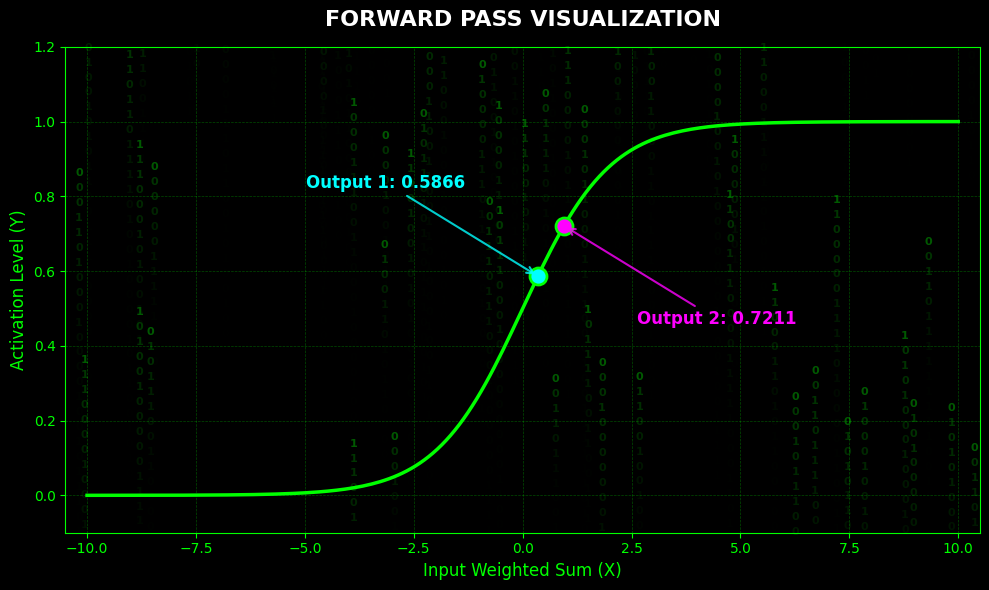

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import random

# 1. Target inference values (Manual Calculation Match)
x_sums = [0.35, 0.95]
y_outs = [0.5866, 0.7211]

# 2. Environment & theme configuration
fig, ax = plt.subplots(figsize=(10, 6))
plt.style.use('dark_background')

# Set background to pure black for maximum contrast
BG_COLOR = '#000000'
NEON_GREEN = '#00FF00'
NEON_BLUE = '#00FFFF'
NEON_PINK = '#FF00FF'
TEXT_WHITE = '#FFFFFF'

ax.set_facecolor(BG_COLOR)
fig.patch.set_facecolor(BG_COLOR)

# Set strict axis limits
X_MIN, X_MAX = -10.5, 10.5
Y_MIN, Y_MAX = -0.1, 1.2
ax.set_xlim(X_MIN, X_MAX)
ax.set_ylim(Y_MIN, Y_MAX)

# 3. Static Matrix Background Generation (Dimmed wallpaper effect)
num_streams = 100 
for _ in range(num_streams):
    x_pos = random.uniform(X_MIN, X_MAX)
    stream_len = random.randint(10, 40)
    y_start = random.uniform(Y_MAX * 0.1, Y_MAX * 2.0)
    
    for j in range(stream_len):
        char_y = y_start - j * 0.04
        if char_y < Y_MIN or char_y > Y_MAX:
            continue
            
        char = random.choice(['0', '1'])
        fade = j / stream_len
        
        g = int(100 * (1 - fade) + 10 * fade)
        color = f'#00{g:02x}00'
        alpha = max(0.05, 0.6 - fade * 1.2)
        
        if j == 0:
            color = '#008000'
            alpha = 0.7
            
        ax.text(x_pos, char_y, char, color=color, alpha=alpha, 
                fontsize=8, fontweight='bold', ha='center', va='center', zorder=1)

# 4. Grid & axes styling
ax.grid(color=NEON_GREEN, linestyle='--', linewidth=0.5, alpha=0.3, zorder=2)
for spine in ax.spines.values():
    spine.set_color(NEON_GREEN)
ax.tick_params(colors=NEON_GREEN)

# 5. Sigmoid activation curve
x_val = np.linspace(-10, 10, 200)
y_val = 1 / (1 + np.exp(-x_val))
ax.plot(x_val, y_val, color=NEON_GREEN, linewidth=2.5, zorder=3)

# 6. Data points mapping 
ax.scatter(x_sums[0], y_outs[0], color=NEON_BLUE, s=150, edgecolors=NEON_GREEN, linewidth=2, zorder=4)
ax.scatter(x_sums[1], y_outs[1], color=NEON_PINK, s=150, edgecolors=NEON_GREEN, linewidth=2, zorder=4)

# 7. Annotations & typography
ax.set_title('FORWARD PASS VISUALIZATION', color=TEXT_WHITE, fontsize=16, fontweight='bold', pad=15)
ax.set_ylabel('Activation Level (Y)', color=NEON_GREEN, fontsize=12)
ax.set_xlabel('Input Weighted Sum (X)', color=NEON_GREEN, fontsize=12)

# --- BULLETPROOF LABELS WITH ARROWS ---
ax.annotate(f"Output 1: {y_outs[0]:.4f}", 
            xy=(x_sums[0], y_outs[0]), 
            xytext=(x_sums[0] - 3.5, y_outs[0] + 0.25), 
            color=NEON_BLUE, fontsize=12, fontweight='bold',
            arrowprops=dict(arrowstyle="->", color=NEON_BLUE, lw=1.5, alpha=0.8),
            ha='center', va='center', zorder=5)

ax.annotate(f"Output 2: {y_outs[1]:.4f}", 
            xy=(x_sums[1], y_outs[1]), 
            xytext=(x_sums[1] + 3.5, y_outs[1] - 0.25), 
            color=NEON_PINK, fontsize=12, fontweight='bold',
            arrowprops=dict(arrowstyle="->", color=NEON_PINK, lw=1.5, alpha=0.8),
            ha='center', va='center', zorder=5)

plt.tight_layout()

# --- SAVE TO FILE ---
# This saves the figure to the project directory for GitHub README visibility
plt.savefig('screenshot.png', dpi=300, bbox_inches='tight')

# Display result
plt.show()